In [1]:
import os
import numpy as np
from util import *
import random
import gc
import copy as c
import pickle
import json
from sklearn.metrics import precision_recall_curve, log_loss, auc, precision_score, recall_score, f1_score
from scipy.signal import argrelextrema
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tabulate import tabulate
import torch

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


In [2]:
shuffle = False
seed = random.randint(1,100000)

valid_txt_fp = 'sym/songs/songs_valid.txt'

max_chunk=500
min_chunk=50
narrow_types=4
audio_radius=10

ignore_classes = []
step_classes = []
for i in range(256):
    unhot = list(unravel_onehot(i, 4))
    if '2' not in unhot and '3' not in unhot:
        ignore_classes.append(i)
    else:
        step_classes.append(i)

print(ignore_classes)

[0, 1, 4, 5, 16, 17, 20, 21, 64, 65, 68, 69, 80, 81, 84, 85]


In [3]:
# Load the saved dictionary
metrics_save_path = 'sym_keras_metrics(temp).pkl'

with open(metrics_save_path, 'rb') as f:
    keras_metric_dict = pickle.load(f)

print("Successfully loaded Keras metric_dict! Ready for comparison tables.")
print(keras_metric_dict.keys())

# --- 1. Raw Sample-Weighted Prediction Metrics ---
Accs_ddcl = keras_metric_dict['ddcl']['acc']
Accs_ddc = keras_metric_dict['ddc']['acc']
HoldAccs_ddcl = keras_metric_dict['ddcl']['hold_acc']
HoldAccs_ddc = keras_metric_dict['ddc']['hold_acc']
StepAccs_ddcl = keras_metric_dict['ddcl']['step_acc']
StepAccs_ddc = keras_metric_dict['ddc']['step_acc']
losses_ddcl = keras_metric_dict['ddcl']['loss']
losses_ddc = keras_metric_dict['ddc']['loss']
accuracy_dict_ddcl = keras_metric_dict['ddcl']['acc_dict']
accuracy_dict_ddc = keras_metric_dict['ddc']['acc_dict']

# --- 2. Macro Chart-Level Metrics ---
Accs_ddcl_chart = keras_metric_dict['ddcl']['acc_chart']
Accs_ddc_chart = keras_metric_dict['ddc']['acc_chart']
HoldAccs_ddcl_chart = keras_metric_dict['ddcl']['hold_acc_chart']
HoldAccs_ddc_chart = keras_metric_dict['ddc']['hold_acc_chart']
StepAccs_ddcl_chart = keras_metric_dict['ddcl']['step_acc_chart']
StepAccs_ddc_chart = keras_metric_dict['ddc']['step_acc_chart']
losses_ddcl_chart = keras_metric_dict['ddcl']['loss_chart']
losses_ddc_chart = keras_metric_dict['ddc']['loss_chart']

# --- 3. Downstream Distribution Lists ---
raw_chart_lists_ddcl = keras_metric_dict['ddcl']['raw_chart_lists']
raw_chart_lists_ddc = keras_metric_dict['ddc']['raw_chart_lists']


def load_chart(fp):
    """Load charts and features from a file path and normalize feats."""
    with open(fp, 'rb') as f:
        loaded = pickle.load(f)
    charts, feats_fp = loaded[0], loaded[1]
    with open(feats_fp, 'rb') as f:
        feats = pickle.load(f)
    mean = np.mean(feats, axis=0)
    std = np.std(feats, axis=0)
    feats = (feats - mean) / std
    del loaded
    return charts, feats

Successfully loaded Keras metric_dict! Ready for comparison tables.
dict_keys(['ddc', 'ddcl'])


In [24]:
from sym_big import *
# 1. Match the exact architecture hyperparameters used in sym_old_update.py
config = ModelConfig(
    d_model=256,       # Matches the training configuration
    n_heads=8,
    n_self_pre=4,
    n_self_post=4,
    n_cross=2,
    n_self_audio_pre=2,
    conv_layers=1,
    VQ_dim=256,
)

# 2. Instantiate the model structural architecture
sym_model = GPTStyleAudioModel(3, config)


# 3. Resolve the path to your best checkpoint file
checkpoint_path = 'trained_models/sym_bigger_best_avg.pt'

# 4. Load the weights state dictionary into the model
if os.path.exists(checkpoint_path):
    torch.serialization.add_safe_globals([np.core.multiarray.scalar])
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'), weights_only=False)
    
    # Extract the nested model state dictionary
    if isinstance(checkpoint, dict) and 'model' in checkpoint:
        state_dict_to_load = checkpoint['model']
    else:
        state_dict_to_load = checkpoint

    # Pull current state dictionary structure
    model_state = sym_model.state_dict()
    
    # Filter matching parameters
    filtered_state = {
        k: v for k, v in state_dict_to_load.items() 
        if k in model_state and model_state[k].shape == v.shape
    }
    
    # --- DETAILED MISMATCH / MISSING KEY LOGGER ---
    missing_or_shifted = [k for k in model_state.keys() if k not in filtered_state]
    if missing_or_shifted:
        print(f"Warning: {len(missing_or_shifted)} layer(s) mismatched/missing from checkpoint.")
        print("List of missing/mismatched layers remaining randomly initialized:")
        for idx, layer_name in enumerate(missing_or_shifted, 1):
            print(f"  {idx}. {layer_name}")
        print("-" * 50)
    
    # Load parameters safely into the model structure
    sym_model.load_state_dict(filtered_state, strict=True)
    print(f"Successfully loaded best checkpoint weights from: {checkpoint_path}")
    
    if isinstance(checkpoint, dict):
        epoch = checkpoint.get('epoch', 'N/A')
        val_acc_step0 = checkpoint.get('best_val_acc_step0', 'N/A')
        print(f"Checkpoint info -> Saved at Epoch: {epoch} | Best Step-0 Val Acc: {val_acc_step0}")
else:
    raise FileNotFoundError(f"Could not find a checkpoint file at {checkpoint_path}.")

Successfully loaded best checkpoint weights from: trained_models/sym_bigger_best_avg.pt
Checkpoint info -> Saved at Epoch: 18 | Best Step-0 Val Acc: 0.6220055297718969


In [5]:
from sym_generators import split_chunks

# 1. Initialize data generator parameters
valid_txt_fp = 'sym/songs/songs_valid.txt'
vld_ds = get_dataset_fp_list(valid_txt_fp)
use_diff = False

# 3. Initialize Device Environment & Evaluation State
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sym_model.to(device)
sym_model.eval()

# Chart-level lists (Stores macro average per entire chart)
losses_chart = []
Accs_chart = {1: [], 2: [], 3: [], 5: []}
HoldAccs_chart = []
StepAccs_chart = []
accuracy_dict = {}

# Raw totals tracking (Sample-weighted prediction level tracking)
total_samples = 0
total_loss_accum = 0.0
total_correct_samples = {1: 0.0, 2: 0.0, 3: 0.0, 5: 0.0}
total_hold_correct = 0.0
total_hold_samples = 0
total_step_correct = 0.0
total_step_samples = 0

# Set up sets for O(1) matching against masked arrays
ignore_classes_set = set(ignore_classes)
step_classes_set = set(step_classes)
pred_steps = sym_model.pred_steps

# 4. Iterate Over the Native Refactored Generator List
with torch.no_grad():
    for fp in tqdm(vld_ds):
        try:
            # Unpack stream tuple maps
            charts, feats = load_chart(fp)
        except StopIteration:
            break

        for chart in charts:
            newsong = [[a[i] for a in chart] for i in range(3)]
            if len(newsong[0]) == 0:
                continue

            try:
                diff = chart[0][3]
            except:
                diff = 0

            newsong[0].append(0)
            newsong[0] = [[newsong[0][i], newsong[0][i+1]] for i in range(len(newsong[0])-1)]
            newsong[1] = [sparse_to_categorical(sparceify([int(a) for a in list(b)]), (narrow_types**4)-1)
                           for b in newsong[1]]

            newsong[2] = [make_onset_feature_context(feats, int(slice), audio_radius)
                           for slice in newsong[2]]
            
            if len(newsong[0]) > max_chunk:
                chunk_buffer = split_chunks(newsong, min_len=min_chunk, max_len=max_chunk)
            else:
                chunk_buffer = [newsong]

            # Temporary accumulator bins for the current chart across all its chunks
            chart_total_samples = 0
            chart_loss_accum = 0.0
            chart_correct = {1: 0.0, 2: 0.0, 3: 0.0, 5: 0.0}
            chart_hold_correct = 0.0
            chart_hold_samples = 0
            chart_step_correct = 0.0
            chart_step_samples = 0

            for chunk in chunk_buffer:
                ns0, ns1, ns2 = chunk
                ns2, ns0, ns1 = np.array(ns2), np.array(ns0), np.array(ns1)
                
                # Construct batch dimensions and move to device
                audio = torch.as_tensor(ns2, dtype=torch.float32).unsqueeze(0).to(device)
                aux   = torch.as_tensor(ns0, dtype=torch.float32).unsqueeze(0).to(device)
        
                target_ids_np = ns1.argmax(axis=-1).astype(np.int64) if ns1.ndim == 2 else ns1.astype(np.int64)
                T = int(target_ids_np.shape[0])
                
                token_in = np.full((1, T), fill_value=sym_model.bos_id, dtype=np.int64)
                if T > 1:
                    token_in[0, 1:] = target_ids_np[:-1]
        
                token_in_t = torch.as_tensor(token_in, dtype=torch.long).to(device)
                target_t   = torch.as_tensor(target_ids_np, dtype=torch.long).unsqueeze(0).to(device)
                lengths    = torch.tensor([audio.shape[1]], device=device)
        
                logits, _ = sym_model(audio, aux, token_in_t, lengths)
                
                # Calculate Sequence Multi-Step Loss using uniform sequence weights
                uniform_weights = torch.ones(pred_steps, device=device)
                loss_val = sequence_multi_step_loss(logits, target_t, lengths=lengths, step_weights=uniform_weights).item()
        
                # Generate sequence truncation padding mask array
                seq_mask = ~(make_key_padding_mask(lengths, logits.size(1))[0])
        
                # 6. Process Step-1 Multi-Step Lookahead Target Evaluations
                step1_logits = logits[0, seq_mask, 0, :]   # [Valid_Sequence_Steps, Num_Classes]
                step1_targets = target_t[0, seq_mask]      # [Valid_Sequence_Steps]
                T_valid = int(step1_targets.size(0))
                
                if T_valid == 0:
                    continue

                # Compute accuracy matrices for customized Top-K benchmarks
                preds_sorted = step1_logits.argsort(dim=-1, descending=True)
        
                # Top-K True Hit counts inside the chunk
                top1_hits_num = (preds_sorted[:, 0] == step1_targets).float().sum().item()
                top2_hits_num = (preds_sorted[:, :2] == step1_targets.unsqueeze(-1)).any(dim=-1).float().sum().item()
                top3_hits_num = (preds_sorted[:, :3] == step1_targets.unsqueeze(-1)).any(dim=-1).float().sum().item()
                top5_hits_num = (preds_sorted[:, :5] == step1_targets.unsqueeze(-1)).any(dim=-1).float().sum().item()
        
                # 7. Extract Categorical Masked Metrics (Hold & Step Arrays)
                preds_np = preds_sorted[:, 0].cpu().numpy()
                targets_np = step1_targets.cpu().numpy()
        
                chunk_ignore_hits, chunk_ignore_total = 0, 0
                chunk_step_hits, chunk_step_total = 0, 0
        
                for pred, tgt in zip(preds_np, targets_np):
                    if tgt in ignore_classes_set:
                        chunk_ignore_total += 1
                        if pred == tgt: chunk_ignore_hits += 1
                    if tgt in step_classes_set:
                        chunk_step_total += 1
                        if pred == tgt: chunk_step_hits += 1

                # Accumulate current chunk metrics into parent chart container
                chart_total_samples += T_valid
                chart_loss_accum += loss_val * T_valid
                chart_correct[1] += top1_hits_num
                chart_correct[2] += top2_hits_num
                chart_correct[3] += top3_hits_num
                chart_correct[5] += top5_hits_num
                
                chart_hold_correct += chunk_step_hits   # Mapping matches original script logic assignment
                chart_hold_samples += chunk_step_total
                chart_step_correct += chunk_ignore_hits
                chart_step_samples += chunk_ignore_total

            if chart_total_samples == 0:
                continue

            # Compute macro metrics for this specific chart
            c_loss = chart_loss_accum / chart_total_samples
            c_acc1 = chart_correct[1] / chart_total_samples
            c_acc2 = chart_correct[2] / chart_total_samples
            c_acc3 = chart_correct[3] / chart_total_samples
            c_acc5 = chart_correct[5] / chart_total_samples

            # Append to Chart-Level evaluation lists
            losses_chart.append(c_loss)
            Accs_chart[1].append(c_acc1)
            Accs_chart[2].append(c_acc2)
            Accs_chart[3].append(c_acc3)
            Accs_chart[5].append(c_acc5)
            
            if chart_hold_samples > 0:
                HoldAccs_chart.append(chart_hold_correct / chart_hold_samples)
            if chart_step_samples > 0:
                StepAccs_chart.append(chart_step_correct / chart_step_samples)

            if diff in accuracy_dict:
                accuracy_dict[diff].append(c_acc1)
            else:
                accuracy_dict[diff] = [c_acc1]

            # Accumulate globally into Raw Prediction sample-weighted trackers
            total_samples += chart_total_samples
            total_loss_accum += chart_loss_accum
            total_correct_samples[1] += chart_correct[1]
            total_correct_samples[2] += chart_correct[2]
            total_correct_samples[3] += chart_correct[3]
            total_correct_samples[5] += chart_correct[5]
            total_hold_correct += chart_hold_correct
            total_hold_samples += chart_hold_samples
            total_step_correct += chart_step_correct
            total_step_samples += chart_step_samples

# 8. Compute Final Aggregated Summaries (Raw Prediction Metrics Mapping)
losses = total_loss_accum / total_samples if total_samples > 0 else 0.0
Accs = {k: total_correct_samples[k] / total_samples for k in [1, 2, 3, 5]}
HoldAccs = total_hold_correct / total_hold_samples if total_hold_samples > 0 else 0.0
StepAccs = total_step_correct / total_step_samples if total_step_samples > 0 else 0.0

print("\n================= CHART AVERAGES METRICS REPORT ================")
print(f'avg loss (chart): {np.mean(losses_chart):.5f}')
print(f'avg acc (chart):  {np.mean(Accs_chart[1])*100:.2f}%')
print(f'avg acc2 (chart): {np.mean(Accs_chart[2])*100:.2f}%')
print(f'avg acc3 (chart): {np.mean(Accs_chart[3])*100:.2f}%')
print(f'avg acc5 (chart): {np.mean(Accs_chart[5])*100:.2f}%')
print(f'avg HoldAcc (chart): {np.mean(HoldAccs_chart)*100:.2f}%' if HoldAccs_chart else 'avg HoldAcc (chart): N/A')
print(f'avg StepAcc (chart): {np.mean(StepAccs_chart)*100:.2f}%' if StepAccs_chart else 'avg StepAcc (chart): N/A')

print("\n=================== RAW SAMPLE AVERAGES REPORT ===================")
print(f'raw avg loss: {losses:.5f}')
print(f'raw avg acc:  {Accs[1]*100:.2f}%')
print(f'raw avg acc2: {Accs[2]*100:.2f}%')
print(f'raw avg acc3: {Accs[3]*100:.2f}%')
print(f'raw avg acc5: {Accs[5]*100:.2f}%')
print(f'raw avg HoldAcc: {HoldAccs*100:.2f}%' if total_hold_samples > 0 else 'raw avg HoldAcc: N/A')
print(f'raw avg StepAcc: {StepAccs*100:.2f}%' if total_step_samples > 0 else 'raw avg StepAcc: N/A')

print("\nMacro-Chart Accuracy Breakdown by Track/Chart Difficulty:")
print("-" * 55)
for d_level in sorted(accuracy_dict.keys()):
    d_avg = np.mean(accuracy_dict[d_level]) * 100
    print(f"  Difficulty Level {d_level:<2} Macro Top-1 Accuracy: {d_avg:.2f}%")
print("==================================================================")

  0%|                                                                                                                                                                                          | 0/24 [00:00<?, ?it/s]/home/miguelomalley/pythonl/lib/python3.10/site-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:15<00:00,  1.57it/s]


================= CHART AVERAGES METRICS REPORT ================
avg loss (chart): 1.93428
avg acc (chart):  60.58%
avg acc2 (chart): 83.37%
avg acc3 (chart): 90.97%
avg acc5 (chart): 95.58%
avg HoldAcc (chart): 37.78%
avg StepAcc (chart): 62.49%

=================== RAW SAMPLE AVERAGES REPORT ===================
raw avg loss: 1.98499
raw avg acc:  59.08%
raw avg acc2: 82.59%
raw avg acc3: 90.33%
raw avg acc5: 94.98%
raw avg HoldAcc: 37.82%
raw avg StepAcc: 62.04%

Macro-Chart Accuracy Breakdown by Track/Chart Difficulty:
-------------------------------------------------------
  Difficulty Level 1  Macro Top-1 Accuracy: 69.66%
  Difficulty Level 3  Macro Top-1 Accuracy: 62.85%
  Difficulty Level 4  Macro Top-1 Accuracy: 68.33%
  Difficulty Level 5  Macro Top-1 Accuracy: 67.01%
  Difficulty Level 6  Macro Top-1 Accuracy: 58.91%
  Difficulty Level 7  Macro Top-1 Accuracy: 64.41%
  Difficulty Level 8  Macro Top-1 Accuracy: 59.07%
  Difficulty Level 9  Macro Top-1 Accuracy: 56.71%
  Diffi

In [6]:
import sym_smaller as ss
# 1. Match the exact architecture hyperparameters used in sym_old_update.py
import __main__
__main__.ModelConfig = ss.ModelConfig
config = ss.ModelConfig(
    d_model=256,               # Base hidden dimensionality
    n_heads=8,
    n_self_pre=4,
    n_self_post=4,
    n_cross=2,
    n_self_audio_pre=2,        # Audio context cross depth
    VQ_dim=256,
    conv_layers=1)

# 2. Instantiate the model structural architecture
sym_model = ss.GPTStyleAudioModel(3, config)

# 3. Resolve the path to your best checkpoint file
checkpoint_path = 'trained_models/sym_gpt_small_new_best_avg.pt'

# 4. Load the weights state dictionary into the model
if os.path.exists(checkpoint_path):
    torch.serialization.add_safe_globals([np.core.multiarray.scalar])
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'), weights_only=False)
    
    # Extract the nested model state dictionary
    if isinstance(checkpoint, dict) and 'model' in checkpoint:
        state_dict_to_load = checkpoint['model']
    else:
        state_dict_to_load = checkpoint

    # Pull current state dictionary structure
    model_state = sym_model.state_dict()
    
    # Filter matching parameters
    filtered_state = {
        k: v for k, v in state_dict_to_load.items() 
        if k in model_state and model_state[k].shape == v.shape
    }
    
    # --- DETAILED MISMATCH / MISSING KEY LOGGER ---
    missing_or_shifted = [k for k in model_state.keys() if k not in filtered_state]
    if missing_or_shifted:
        print(f"Warning: {len(missing_or_shifted)} layer(s) mismatched/missing from checkpoint.")
        print("List of missing/mismatched layers remaining randomly initialized:")
        for idx, layer_name in enumerate(missing_or_shifted, 1):
            print(f"  {idx}. {layer_name}")
        print("-" * 50)
    
    # Load parameters safely into the model structure
    sym_model.load_state_dict(filtered_state, strict=False)
    print(f"Successfully loaded best checkpoint weights from: {checkpoint_path}")
    
    if isinstance(checkpoint, dict):
        epoch = checkpoint.get('epoch', 'N/A')
        val_acc_step0 = checkpoint.get('best_val_acc_step0', 'N/A')
        print(f"Checkpoint info -> Saved at Epoch: {epoch} | Best Step-0 Val Acc: {val_acc_step0}")
else:
    raise FileNotFoundError(f"Could not find a checkpoint file at {checkpoint_path}.")

Successfully loaded best checkpoint weights from: trained_models/sym_gpt_small_new_best_avg.pt
Checkpoint info -> Saved at Epoch: 19 | Best Step-0 Val Acc: 0.6124617359533919


In [7]:
# 2. Instantiate the model structural architecture
from sym_encoders import BasicEncoder

sym_model_small = ss.GPTStyleAudioModel(3, config)
sym_model_small.audio_enc = BasicEncoder(
           in_channels=3,
            d_model=256,
        )
#print(sym_model_small.audio_enc)

# 3. Resolve the path to your best checkpoint file
checkpoint_path = 'trained_models/sym_gpt_small_new_best_avg.pt'

# 4. Load the weights state dictionary into the model
if os.path.exists(checkpoint_path):
    torch.serialization.add_safe_globals([np.core.multiarray.scalar])
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'), weights_only=False)
    
    # Extract the nested model state dictionary
    if isinstance(checkpoint, dict) and 'model' in checkpoint:
        state_dict_to_load = checkpoint['model']
    else:
        state_dict_to_load = checkpoint

    # Pull current state dictionary structure
    model_state = sym_model_small.state_dict()
    
    # Filter matching parameters
    filtered_state = {
        k: v for k, v in state_dict_to_load.items() 
        if k in model_state and model_state[k].shape == v.shape
    }
    
    # --- DETAILED MISMATCH / MISSING KEY LOGGER ---
    missing_or_shifted = [k for k in model_state.keys() if k not in filtered_state]
    if missing_or_shifted:
        print(f"Warning: {len(missing_or_shifted)} layer(s) mismatched/missing from checkpoint.")
        print("List of missing/mismatched layers remaining randomly initialized:")
        for idx, layer_name in enumerate(missing_or_shifted, 1):
            print(f"  {idx}. {layer_name}")
        print("-" * 50)
    
    # Load parameters safely into the model structure
    sym_model_small.load_state_dict(filtered_state, strict=False)
    print(f"Successfully loaded best checkpoint weights from: {checkpoint_path}")
    
    if isinstance(checkpoint, dict):
        epoch = checkpoint.get('epoch', 'N/A')
        val_acc_step0 = checkpoint.get('best_val_acc_step0', 'N/A')
        print(f"Checkpoint info -> Saved at Epoch: {epoch} | Best Step-0 Val Acc: {val_acc_step0}")
else:
    raise FileNotFoundError(f"Could not find a checkpoint file at {checkpoint_path}.")

Successfully loaded best checkpoint weights from: trained_models/sym_gpt_small_new_best_avg.pt
Checkpoint info -> Saved at Epoch: 19 | Best Step-0 Val Acc: 0.6124617359533919


In [8]:
from sym_generators import split_chunks

# 1. Initialize data generator parameters
valid_txt_fp = 'sym/songs/songs_valid.txt'
vld_ds = get_dataset_fp_list(valid_txt_fp)
use_diff = False

# 3. Initialize Device Environment & Evaluation State
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sym_model_small.to(device)
sym_model_small.eval()

# Chart-level lists (Stores macro average per entire chart)
losses_small_chart = []
Accs_small_chart = {1: [], 2: [], 3: [], 5: []}
HoldAccs_small_chart = []
StepAccs_small_chart = []
accuracy_dict_small = {}

# Raw totals tracking (Sample-weighted prediction level tracking)
total_samples_small = 0
total_loss_accum_small = 0.0
total_correct_samples_small = {1: 0.0, 2: 0.0, 3: 0.0, 5: 0.0}
total_hold_correct_small = 0.0
total_hold_samples_small = 0
total_step_correct_small = 0.0
total_step_samples_small = 0

# Set up sets for O(1) matching against masked arrays
ignore_classes_set = set(ignore_classes)
step_classes_set = set(step_classes)
pred_steps = sym_model.pred_steps

# 4. Iterate Over the Native Refactored Generator List
with torch.no_grad():
    for fp in tqdm(vld_ds):
        try:
            # Unpack stream tuple maps
            charts, feats = load_chart(fp)
        except StopIteration:
            break

        for chart in charts:
            newsong = [[a[i] for a in chart] for i in range(3)]
            if len(newsong[0]) == 0:
                continue

            try:
                diff = chart[0][3]
            except:
                diff = 0

            newsong[0].append(0)
            newsong[0] = [[newsong[0][i], newsong[0][i+1]] for i in range(len(newsong[0])-1)]
            newsong[1] = [sparse_to_categorical(sparceify([int(a) for a in list(b)]), (narrow_types**4)-1)
                           for b in newsong[1]]

            newsong[2] = [make_onset_feature_context(feats, int(slice), audio_radius)
                           for slice in newsong[2]]
            
            if len(newsong[0]) > max_chunk:
                chunk_buffer = split_chunks(newsong, min_len=min_chunk, max_len=max_chunk)
            else:
                chunk_buffer = [newsong]

            # Temporary accumulator bins for the current chart across all its chunks
            chart_total_samples = 0
            chart_loss_accum = 0.0
            chart_correct = {1: 0.0, 2: 0.0, 3: 0.0, 5: 0.0}
            chart_hold_correct = 0.0
            chart_hold_samples = 0
            chart_step_correct = 0.0
            chart_step_samples = 0

            for chunk in chunk_buffer:
                ns0, ns1, ns2 = chunk
                ns2, ns0, ns1 = np.array(ns2), np.array(ns0), np.array(ns1)
                
                # Construct batch dimensions and move to device
                audio = torch.as_tensor(ns2, dtype=torch.float32).unsqueeze(0).to(device)
                aux   = torch.as_tensor(ns0, dtype=torch.float32).unsqueeze(0).to(device)
        
                target_ids_np = ns1.argmax(axis=-1).astype(np.int64) if ns1.ndim == 2 else ns1.astype(np.int64)
                T = int(target_ids_np.shape[0])
                
                token_in = np.full((1, T), fill_value=sym_model.bos_id, dtype=np.int64)
                if T > 1:
                    token_in[0, 1:] = target_ids_np[:-1]
        
                token_in_t = torch.as_tensor(token_in, dtype=torch.long).to(device)
                target_t   = torch.as_tensor(target_ids_np, dtype=torch.long).unsqueeze(0).to(device)
                lengths    = torch.tensor([audio.shape[1]], device=device)
        
                logits, _ = sym_model_small(audio, aux, token_in_t, lengths)
                
                # Calculate Sequence Multi-Step Loss using uniform sequence weights
                uniform_weights = torch.ones(pred_steps, device=device)
                loss_val = sequence_multi_step_loss(logits, target_t, lengths=lengths, step_weights=uniform_weights).item()
        
                # Generate sequence truncation padding mask array
                seq_mask = ~(make_key_padding_mask(lengths, logits.size(1))[0])
        
                # 6. Process Step-1 Multi-Step Lookahead Target Evaluations
                step1_logits = logits[0, seq_mask, 0, :]   # [Valid_Sequence_Steps, Num_Classes]
                step1_targets = target_t[0, seq_mask]      # [Valid_Sequence_Steps]
                T_valid = int(step1_targets.size(0))
                
                if T_valid == 0:
                    continue

                # Compute accuracy matrices for customized Top-K benchmarks
                preds_sorted = step1_logits.argsort(dim=-1, descending=True)
        
                # Top-K True Hit counts inside the chunk
                top1_hits_num = (preds_sorted[:, 0] == step1_targets).float().sum().item()
                top2_hits_num = (preds_sorted[:, :2] == step1_targets.unsqueeze(-1)).any(dim=-1).float().sum().item()
                top3_hits_num = (preds_sorted[:, :3] == step1_targets.unsqueeze(-1)).any(dim=-1).float().sum().item()
                top5_hits_num = (preds_sorted[:, :5] == step1_targets.unsqueeze(-1)).any(dim=-1).float().sum().item()
        
                # 7. Extract Categorical Masked Metrics (Hold & Step Arrays)
                preds_np = preds_sorted[:, 0].cpu().numpy()
                targets_np = step1_targets.cpu().numpy()
        
                chunk_ignore_hits, chunk_ignore_total = 0, 0
                chunk_step_hits, chunk_step_total = 0, 0
        
                for pred, tgt in zip(preds_np, targets_np):
                    if tgt in ignore_classes_set:
                        chunk_ignore_total += 1
                        if pred == tgt: chunk_ignore_hits += 1
                    if tgt in step_classes_set:
                        chunk_step_total += 1
                        if pred == tgt: chunk_step_hits += 1

                # Accumulate current chunk metrics into parent chart container
                chart_total_samples += T_valid
                chart_loss_accum += loss_val * T_valid
                chart_correct[1] += top1_hits_num
                chart_correct[2] += top2_hits_num
                chart_correct[3] += top3_hits_num
                chart_correct[5] += top5_hits_num
                
                chart_hold_correct += chunk_step_hits
                chart_hold_samples += chunk_step_total
                chart_step_correct += chunk_ignore_hits
                chart_step_samples += chunk_ignore_total

            if chart_total_samples == 0:
                continue

            # Compute macro metrics for this specific chart
            c_loss = chart_loss_accum / chart_total_samples
            c_acc1 = chart_correct[1] / chart_total_samples
            c_acc2 = chart_correct[2] / chart_total_samples
            c_acc3 = chart_correct[3] / chart_total_samples
            c_acc5 = chart_correct[5] / chart_total_samples

            # Append to Chart-Level evaluation lists
            losses_small_chart.append(c_loss)
            Accs_small_chart[1].append(c_acc1)
            Accs_small_chart[2].append(c_acc2)
            Accs_small_chart[3].append(c_acc3)
            Accs_small_chart[5].append(c_acc5)
            
            if chart_hold_samples > 0:
                HoldAccs_small_chart.append(chart_hold_correct / chart_hold_samples)
            if chart_step_samples > 0:
                StepAccs_small_chart.append(chart_step_correct / chart_step_samples)

            if diff in accuracy_dict_small:
                accuracy_dict_small[diff].append(c_acc1)
            else:
                accuracy_dict_small[diff] = [c_acc1]

            # Accumulate globally into Raw Prediction sample-weighted trackers
            total_samples_small += chart_total_samples
            total_loss_accum_small += chart_loss_accum
            total_correct_samples_small[1] += chart_correct[1]
            total_correct_samples_small[2] += chart_correct[2]
            total_correct_samples_small[3] += chart_correct[3]
            total_correct_samples_small[5] += chart_correct[5]
            total_hold_correct_small += chart_hold_correct
            total_hold_samples_small += chart_hold_samples
            total_step_correct_small += chart_step_correct
            total_step_samples_small += chart_step_samples

# 8. Compute Final Aggregated Summaries (Raw Prediction Metrics Mapping)
losses_small = total_loss_accum_small / total_samples_small if total_samples_small > 0 else 0.0
Accs_small = {k: total_correct_samples_small[k] / total_samples_small for k in [1, 2, 3, 5]}
HoldAccs_small = total_hold_correct_small / total_hold_samples_small if total_hold_samples_small > 0 else 0.0
StepAccs_small = total_step_correct_small / total_step_samples_small if total_step_samples_small > 0 else 0.0

print("\n================= CHART AVERAGES METRICS REPORT (SMALL) ================")
print(f'avg loss (chart): {np.mean(losses_small_chart):.5f}')
print(f'avg acc (chart):  {np.mean(Accs_small_chart[1])*100:.2f}%')
print(f'avg acc2 (chart): {np.mean(Accs_small_chart[2])*100:.2f}%')
print(f'avg acc3 (chart): {np.mean(Accs_small_chart[3])*100:.2f}%')
print(f'avg acc5 (chart): {np.mean(Accs_small_chart[5])*100:.2f}%')
print(f'avg HoldAcc (chart): {np.mean(HoldAccs_small_chart)*100:.2f}%' if HoldAccs_small_chart else 'avg HoldAcc (chart): N/A')
print(f'avg StepAcc (chart): {np.mean(StepAccs_small_chart)*100:.2f}%' if StepAccs_small_chart else 'avg StepAcc (chart): N/A')

print("\n=================== RAW SAMPLE AVERAGES REPORT (SMALL) ===================")
print(f'raw avg loss: {losses_small:.5f}')
print(f'raw avg acc:  {Accs_small[1]*100:.2f}%')
print(f'raw avg acc2: {Accs_small[2]*100:.2f}%')
print(f'raw avg acc3: {Accs_small[3]*100:.2f}%')
print(f'raw avg acc5: {Accs_small[5]*100:.2f}%')
print(f'raw avg HoldAcc: {HoldAccs_small*100:.2f}%' if total_hold_samples_small > 0 else 'raw avg HoldAcc: N/A')
print(f'raw avg StepAcc: {StepAccs_small*100:.2f}%' if total_step_samples_small > 0 else 'raw avg StepAcc: N/A')

print("\nMacro-Chart Accuracy Breakdown by Track/Chart Difficulty (Small):")
print("-" * 55)
for d_level in sorted(accuracy_dict_small.keys()):
    d_avg = np.mean(accuracy_dict_small[d_level]) * 100
    print(f"  Difficulty Level {d_level:<2} Macro Top-1 Accuracy: {d_avg:.2f}%")
print("==================================================================")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:09<00:00,  2.62it/s]


================= CHART AVERAGES METRICS REPORT (SMALL) ================
avg loss (chart): 1.95443
avg acc (chart):  60.05%
avg acc2 (chart): 82.68%
avg acc3 (chart): 90.47%
avg acc5 (chart): 95.27%
avg HoldAcc (chart): 36.90%
avg StepAcc (chart): 62.22%

=================== RAW SAMPLE AVERAGES REPORT (SMALL) ===================
raw avg loss: 2.01093
raw avg acc:  58.13%
raw avg acc2: 81.65%
raw avg acc3: 89.65%
raw avg acc5: 94.46%
raw avg HoldAcc: 34.82%
raw avg StepAcc: 61.38%

Macro-Chart Accuracy Breakdown by Track/Chart Difficulty (Small):
-------------------------------------------------------
  Difficulty Level 1  Macro Top-1 Accuracy: 69.31%
  Difficulty Level 3  Macro Top-1 Accuracy: 63.42%
  Difficulty Level 4  Macro Top-1 Accuracy: 68.74%
  Difficulty Level 5  Macro Top-1 Accuracy: 66.51%
  Difficulty Level 6  Macro Top-1 Accuracy: 60.40%
  Difficulty Level 7  Macro Top-1 Accuracy: 65.18%
  Difficulty Level 8  Macro Top-1 Accuracy: 57.47%
  Difficulty Level 9  Macro Top-1 

In [21]:
import time
import numpy as np
import torch
import gc
import os
from tqdm import tqdm

# 1. Initialize data generator parameters
valid_txt_fp = 'sym/songs/songs_valid.txt'
vld_ds = get_dataset_fp_list(valid_txt_fp)
use_diff = False

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tracking lists for full chart-level timing profiles
generation_times_big = []
generation_times_small = []

# Move models to device and set to evaluation mode
sym_model.to(device)
sym_model.eval()

sym_model_small.to(device)
sym_model_small.eval()

# 4. Iterate Over the Native Refactored Generator List
with torch.no_grad():
    for fp in tqdm(vld_ds, desc="Benchmarking generation"):
        if not os.path.exists(fp):
            continue
            
        try:
            charts, feats = load_chart(fp)
        except StopIteration:
            break

        for chart in charts:
            newsong = [[a[i] for a in chart] for i in range(3)]
            if len(newsong[0]) == 0:
                continue

            try:
                diff = chart[0][3]
            except:
                diff = 0

            newsong[0].append(0)
            newsong[0] = [[newsong[0][i], newsong[0][i+1]] for i in range(len(newsong[0])-1)]
            newsong[1] = [sparse_to_categorical(sparceify([int(a) for a in list(b)]), (narrow_types**4)-1)
                           for b in newsong[1]]

            newsong[2] = [make_onset_feature_context(feats, int(slice), audio_radius)
                           for slice in newsong[2]]
            
            if len(newsong[0]) > max_chunk:
                chunk_buffer = split_chunks(newsong, min_len=min_chunk, max_len=max_chunk)
            else:
                chunk_buffer = [newsong]

            # Accumulators to track total execution time across ALL chunks belonging to this chart
            chart_time_big = 0.0
            chart_time_small = 0.0
            valid_chart = False

            for chunk in chunk_buffer:
                ns0, ns1, ns2 = chunk
                ns2, ns0, ns1 = np.array(ns2), np.array(ns0), np.array(ns1)
                
                # Move numpy slices directly to PyTorch tensors
                audio = torch.as_tensor(ns2, dtype=torch.float32).to(device)
                aux   = torch.as_tensor(ns0, dtype=torch.float32).to(device)
                
                target_ids_np = ns1.argmax(axis=-1).astype(np.int64) if ns1.ndim == 2 else ns1.astype(np.int64)
                T = int(target_ids_np.shape[0])
                
                if T == 0:
                    continue
                
                valid_chart = True
                lengths = torch.tensor([audio.shape[0]], device=device)

                # --- 1. BENCHMARK BIG MODEL GENERATE ---
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                start_big = time.time()
                
                _ = sym_model.generate(
                    audio_steps=audio.unsqueeze(0),
                    aux_steps=aux.unsqueeze(0),
                    max_len=T,
                    lengths=lengths,
                    device=device,
                    temperature=1.0,
                    top_p=0.9
                )
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                chart_time_big += (time.time() - start_big)

                # --- 2. BENCHMARK SMALL MODEL GENERATE ---
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                start_small = time.time()
                
                _ = sym_model_small.generate(
                    audio_steps=audio.unsqueeze(0),
                    aux_steps=aux.unsqueeze(0),
                    max_len=T,
                    lengths=lengths,
                    device=device,
                    temperature=1.0,
                    top_p=0.9
                )
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                chart_time_small += (time.time() - start_small)

            # Only log timing profiles if the chart actually contained valid steps
            if valid_chart:
                generation_times_big.append(chart_time_big)
                generation_times_small.append(chart_time_small)

            del chunk_buffer, newsong
            gc.collect()

# Print timing profile analysis output metrics (now cleanly matching full charts layout)
for name, profiling_list in [("ITGPT BIG MODEL", generation_times_big), ("ITGPT SMALL MODEL", generation_times_small)]:
    print(f"\n================ {name} BENCHMARK ================")
    if profiling_list:
        print(f"Total Charts Sampled:          {len(profiling_list)}")
        print(f"Avg Generation Time per Chart: {np.mean(profiling_list):.4f} seconds")
        print(f"Max Generation Time (Slowest): {np.max(profiling_list):.4f} seconds")
        print(f"Min Generation Time (Fastest): {np.min(profiling_list):.4f} seconds")
    else:
        print("No valid sequences were processed.")
    print("================================================================")

Benchmarking generation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [43:35<00:00, 108.98s/it]


================ ITGPT BIG MODEL BENCHMARK ================
Total Charts Sampled:          296
Avg Generation Time per Chart: 4.3280 seconds
Max Generation Time (Slowest): 18.0619 seconds
Min Generation Time (Fastest): 0.4334 seconds

================ ITGPT SMALL MODEL BENCHMARK ================
Total Charts Sampled:          296
Avg Generation Time per Chart: 4.3361 seconds
Max Generation Time (Slowest): 18.1742 seconds
Min Generation Time (Fastest): 0.4333 seconds


In [26]:
import time
import numpy as np
import torch
import gc
import os
from tqdm import tqdm

# 1. Initialize data generator parameters
valid_txt_fp = 'sym/songs/songs_valid.txt'
vld_ds = get_dataset_fp_list(valid_txt_fp)
use_diff = False

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tracking list for the big model only
generation_times_big = []

# Move big model to device and set to evaluation mode
sym_model.to(device)
sym_model.eval()

# Force clear cache before starting
if device.type == 'cuda':
    torch.cuda.empty_cache()
gc.collect()

# 4. Iterate Over the Native Refactored Generator List
with torch.no_grad():
    for fp in tqdm(vld_ds, desc="Benchmarking big model generation"):
        if not os.path.exists(fp):
            continue
            
        try:
            charts, feats = load_chart(fp)
        except StopIteration:
            break

        for chart in charts:
            newsong = [[a[i] for a in chart] for i in range(3)]
            if len(newsong[0]) == 0:
                continue

            try:
                diff = chart[0][3]
            except:
                diff = 0

            newsong[0].append(0)
            newsong[0] = [[newsong[0][i], newsong[0][i+1]] for i in range(len(newsong[0])-1)]
            newsong[1] = [sparse_to_categorical(sparceify([int(a) for a in list(b)]), (narrow_types**4)-1)
                           for b in newsong[1]]

            newsong[2] = [make_onset_feature_context(feats, int(slice), audio_radius)
                           for slice in newsong[2]]
            
            if len(newsong[0]) > max_chunk:
                chunk_buffer = split_chunks(newsong, min_len=min_chunk, max_len=max_chunk)
            else:
                chunk_buffer = [newsong]

            # Accumulator to track total execution time across ALL chunks for this chart
            chart_time_big = 0.0
            valid_chart = False

            for chunk in chunk_buffer:
                ns0, ns1, ns2 = chunk
                ns2, ns0, ns1 = np.array(ns2), np.array(ns0), np.array(ns1)
                
                # Move numpy slices directly to PyTorch tensors
                audio = torch.as_tensor(ns2, dtype=torch.float32).to(device)
                aux   = torch.as_tensor(ns0, dtype=torch.float32).to(device)
                
                target_ids_np = ns1.argmax(axis=-1).astype(np.int64) if ns1.ndim == 2 else ns1.astype(np.int64)
                T = int(target_ids_np.shape[0])
                
                if T == 0:
                    continue
                
                valid_chart = True
                lengths = torch.tensor([audio.shape[0]], device=device)

                # --- BENCHMARK BIG MODEL GENERATE ---
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                start_big = time.time()
                
                _ = sym_model.generate(
                    audio_steps=audio.unsqueeze(0),
                    aux_steps=aux.unsqueeze(0),
                    max_len=T,
                    lengths=lengths,
                    device=device,
                    temperature=1.0,
                    top_p=0.9
                )
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                chart_time_big += (time.time() - start_big)

            # Log chart metrics
            if valid_chart:
                generation_times_big.append(chart_time_big)

            del chunk_buffer, newsong
            gc.collect()

# Print timing profile analysis output metrics
print("\n================ ITGPT BIG MODEL BENCHMARK ================")
if generation_times_big:
    print(f"Total Charts Sampled:          {len(generation_times_big)}")
    print(f"Avg Generation Time per Chart: {np.mean(generation_times_big):.4f} seconds")
    print(f"Max Generation Time (Slowest): {np.max(generation_times_big):.4f} seconds")
    print(f"Min Generation Time (Fastest): {np.min(generation_times_big):.4f} seconds")
else:
    print("No valid sequences were processed.")
print("================================================================")

Benchmarking big model generation:   0%|                                                                                                                                                       | 0/24 [00:00<?, ?it/s]/home/miguelomalley/pythonl/lib/python3.10/site-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
Benchmarking big model generation: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [22:36<00:00, 56.52s/it]


================ ITGPT BIG MODEL BENCHMARK ================
Total Charts Sampled:          296
Avg Generation Time per Chart: 4.3866 seconds
Max Generation Time (Slowest): 18.4468 seconds
Min Generation Time (Fastest): 0.4382 seconds


In [27]:
print(sym_model.audio_enc)

NewStepConvEncoder(
  (cnn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(7, 3), stride=(1, 1))
    (1): GELU(approximate='none')
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 3), padding=(1, 0))
    (3): GELU(approximate='none')
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): GELU(approximate='none')
    (6): Conv2d(64, 256, kernel_size=(3, 3), stride=(1, 3), padding=(1, 0))
    (7): GELU(approximate='none')
  )
  (pos_emb_time): Embedding(512, 256)
  (pos_emb_freq): Embedding(512, 256)
  (pos_ln): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (vq): ResidualVQ(
    (project_in): Identity()
    (project_out): Identity()
    (layers): ModuleList(
      (0-3): 4 x VectorQuantize(
        (project_in): Identity()
        (project_out): Identity()
        (_codebook): Codebook()
      )
    )
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out

In [9]:
# Prepare a dataframe for seaborn
data = {
    'Accuracy': Accs[1] + Accs_small[1] + Accs_ddcl[1] + Accs_ddc[1],
    #'Hold Accuracy': HoldAccs + HoldAccs_ddc + HoldAccs_diff + HoldAccs_conv3d,
    #'Step Accuracy': StepAccs + StepAccs_ddc + StepAccs_diff + StepAccs_conv3d,
    'Model': (['ITGPT Big'] * len(losses)) + (['ITGPT'] * len(losses_small)) + (['DDCL'] * len(losses_ddcl)) + (['DDC'] * len(losses_ddc))
}

df = pd.DataFrame(data)

# Melt the dataframe to long-form for seaborn
df_melted = pd.melt(df, id_vars='Model', var_name='Metric', value_name='Value')

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Metric', y='Value', hue='Model', data=df_melted)
plt.title('Comparison of Accuracy Between Models')
plt.grid(True)
plt.tight_layout()
plt.savefig('figs/auc_acc_sym.png')
plt.show()

TypeError: object of type 'float' has no len()

In [30]:
import numpy as np
import pandas as pd

# ==============================================================================
# TABLE 1: RAW SAMPLE-WEIGHTED PREDICTION METRICS
# ==============================================================================
data_raw = {
    "Model": ["ITGPT", "ITGPTs", "DDCL", "DDC"],
    "Loss": [
        losses, losses_small, 
        losses_ddcl, losses_ddc
    ],
    "Accuracy": [
        np.mean(Accs[1]), np.mean(Accs_small[1]), 
        np.mean(Accs_ddcl[1]), np.mean(Accs_ddc[1])
    ],
    "Top 2 Accuracy": [
        np.mean(Accs[2]), np.mean(Accs_small[2]), 
        np.mean(Accs_ddcl[2]), np.mean(Accs_ddc[2])
    ],
    "Top 3 Accuracy": [
        np.mean(Accs[3]), np.mean(Accs_small[3]), 
        np.mean(Accs_ddcl[3]), np.mean(Accs_ddc[3])
    ],
    "HoldAcc": [
        HoldAccs if HoldAccs else np.nan, 
        HoldAccs_small if HoldAccs_small else np.nan, 
        HoldAccs_ddcl if HoldAccs_ddcl else np.nan, 
        HoldAccs_ddc if HoldAccs_ddc else np.nan
    ],
    "StepAcc": [
        StepAccs if StepAccs else np.nan, 
        StepAccs_small if StepAccs_small else np.nan, 
        StepAccs_ddcl if StepAccs_ddcl else np.nan, 
        StepAccs_ddc if StepAccs_ddc else np.nan
    ]
}

df_raw = pd.DataFrame(data_raw)
df_raw_rounded = df_raw.copy()
df_raw_rounded.iloc[:, 1:] = df_raw_rounded.iloc[:, 1:].astype(float).round(4)

print("================ RAW SAMPLE-WEIGHTED PREDICTION METRICS ================")
print(df_raw_rounded)

latex_table_raw = df_raw_rounded.to_latex(
    index=False, 
    caption="Model Evaluation Metrics (Raw Sample-Weighted)", 
    label="tab:model_evaluation_raw", 
    column_format="lcccccc"
)
print("\n" + latex_table_raw)


# ==============================================================================
# TABLE 2: MACRO CHART-LEVEL METRICS
# ==============================================================================
data_chart = {
    "Model": ["ITGPT", "ITGPTs", "DDCL", "DDC"],
    "Loss": [
        np.mean(losses_chart), np.mean(losses_small_chart), 
        np.mean(losses_ddcl_chart), np.mean(losses_ddc_chart)
    ],
    "Accuracy": [
        np.mean(Accs_chart[1]), np.mean(Accs_small_chart[1]), 
        np.mean(Accs_ddcl_chart[1]), np.mean(Accs_ddc_chart[1])
    ],
    "Top 2 Accuracy": [
        np.mean(Accs_chart[2]), np.mean(Accs_small_chart[2]), 
        np.mean(Accs_ddcl_chart[2]), np.mean(Accs_ddc_chart[2])
    ],
    "Top 3 Accuracy": [
        np.mean(Accs_chart[3]), np.mean(Accs_small_chart[3]), 
        np.mean(Accs_ddcl_chart[3]), np.mean(Accs_ddc_chart[3])
    ],
    "HoldAcc": [
        np.mean(HoldAccs_chart) if HoldAccs_chart else np.nan, 
        np.mean(HoldAccs_small_chart) if HoldAccs_small_chart else np.nan, 
        np.mean(HoldAccs_ddcl_chart) if HoldAccs_ddcl_chart else np.nan, 
        np.mean(HoldAccs_ddc_chart) if HoldAccs_ddc_chart else np.nan
    ],
    "StepAcc": [
        np.mean(StepAccs_chart) if StepAccs_chart else np.nan, 
        np.mean(StepAccs_small_chart) if StepAccs_small_chart else np.nan, 
        np.mean(StepAccs_ddcl_chart) if StepAccs_ddcl_chart else np.nan, 
        np.mean(StepAccs_ddc_chart) if StepAccs_ddc_chart else np.nan
    ]
}

df_chart = pd.DataFrame(data_chart)
df_chart_rounded = df_chart.copy()
df_chart_rounded.iloc[:, 1:] = df_chart_rounded.iloc[:, 1:].astype(float).round(4)

print("\n======================= MACRO CHART-LEVEL METRICS =======================")
print(df_chart_rounded)

latex_table_chart = df_chart_rounded.to_latex(
    index=False, 
    caption="Model Evaluation Metrics (Macro Chart-Level)", 
    label="tab:model_evaluation_chart", 
    column_format="lcccccc"
)
print("\n" + latex_table_chart)

================ RAW SAMPLE-WEIGHTED PREDICTION METRICS ================
    Model    Loss  Accuracy  Top 2 Accuracy  Top 3 Accuracy  HoldAcc  StepAcc
0   ITGPT  1.9850    0.5908          0.8259          0.9033   0.3782   0.6204
1  ITGPTs  2.0109    0.5813          0.8165          0.8965   0.3482   0.6138
2    DDCL  1.1924    0.5533          0.8100          0.9001   0.4115   0.5683
3     DDC  1.5366    0.4523          0.7135          0.8330   0.1891   0.4840

\begin{table}
\caption{Model Evaluation Metrics (Raw Sample-Weighted)}
\label{tab:model_evaluation_raw}
\begin{tabular}{lcccccc}
\toprule
Model & Loss & Accuracy & Top 2 Accuracy & Top 3 Accuracy & HoldAcc & StepAcc \\
\midrule
ITGPT & 1.985000 & 0.590800 & 0.825900 & 0.903300 & 0.378200 & 0.620400 \\
ITGPTs & 2.010900 & 0.581300 & 0.816500 & 0.896500 & 0.348200 & 0.613800 \\
DDCL & 1.192400 & 0.553300 & 0.810000 & 0.900100 & 0.411500 & 0.568300 \\
DDC & 1.536600 & 0.452300 & 0.713500 & 0.833000 & 0.189100 & 0.484000 \\
\bottomrul

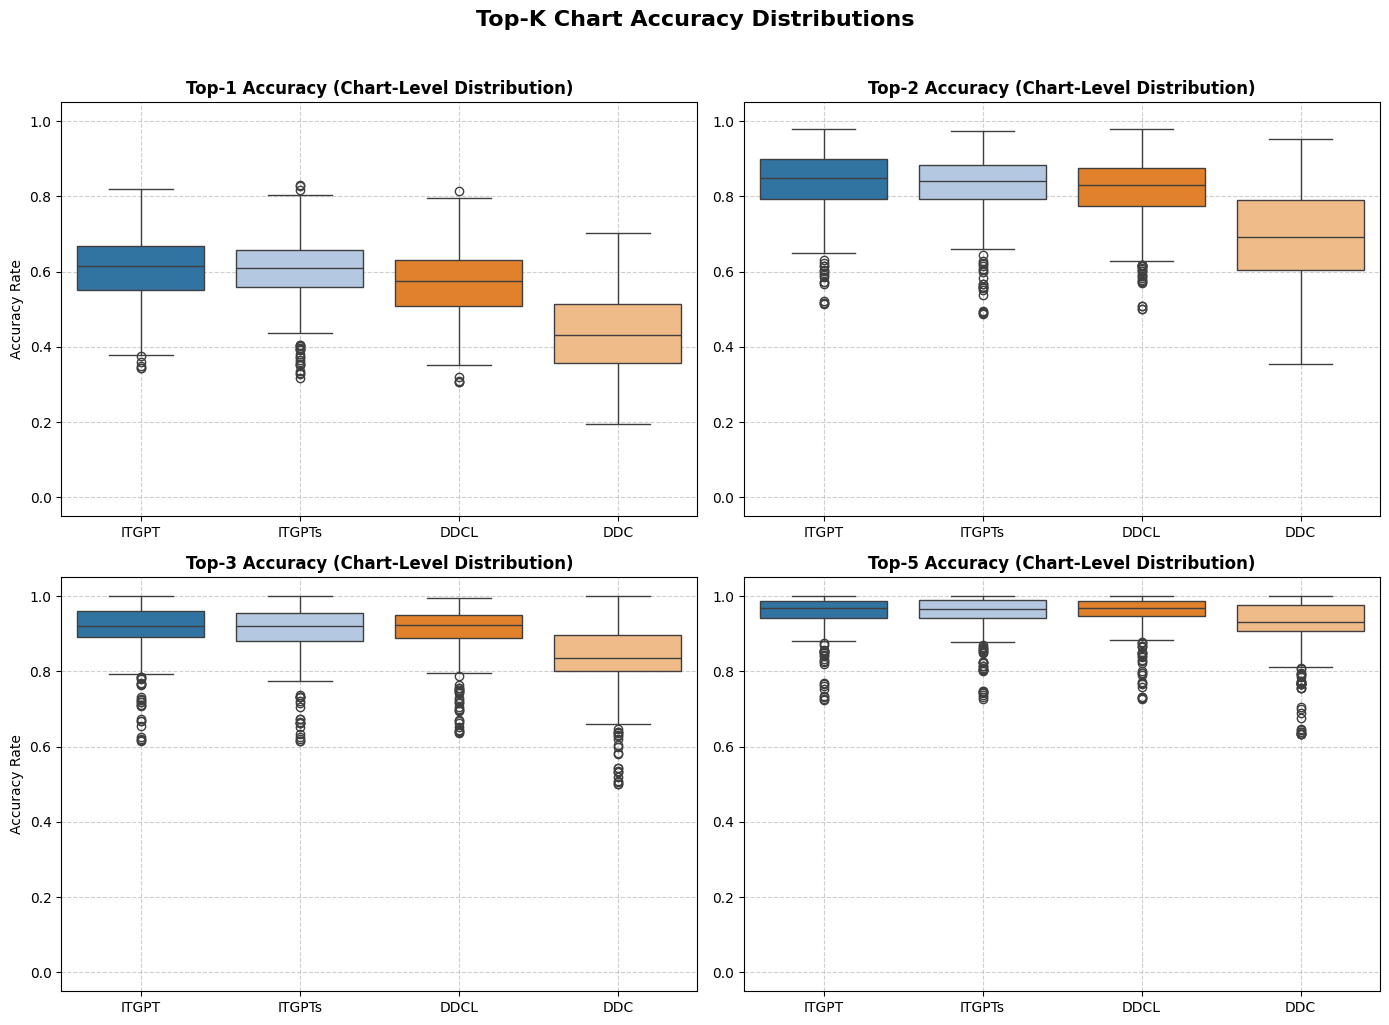

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define top_ks to plot
top_ks = [1, 2, 3, 5]
model_names = ['ITGPT', 'ITGPTs', 'DDCL', 'DDC']

# Point to the actual distribution lists for all models
acc_sources = {
    'ITGPT': Accs_chart,                               # List from live PyTorch loop
    'ITGPTs': Accs_small_chart,                             # List from live PyTorch loop
    'DDCL': raw_chart_lists_ddcl['accs'],                 # Full distribution list from Keras pickle
    'DDC': raw_chart_lists_ddc['accs'],                   # Full distribution list from Keras pickle
}

# Define a clean color palette for the models
model_colors = {
    'ITGPT': '#1f77b4',  # Royal Blue
    'ITGPTs': '#aec7e8',      # Light Blue
    'DDCL': '#ff7f0e',       # Dark Orange
    'DDC': '#ffbb78'         # Light Orange
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, k in zip(axes, top_ks):
    values = []
    models = []
    
    for name in model_names:
        # Pull out the un-averaged distribution list of chart accuracies for Top-K
        vals = acc_sources[name][k]
        values.extend(vals)
        models.extend([name] * len(vals))

    # Construct the tracking dataframe for Seaborn
    df_k = pd.DataFrame({'Model': models, 'Accuracy': values})
    
    # Plot with specific model color assignments
    sns.boxplot(
        x='Model', 
        y='Accuracy', 
        data=df_k, 
        ax=ax, 
        palette=model_colors,
        hue='Model',
        legend=False
    )
    
    ax.set_title(f'Top-{k} Accuracy (Chart-Level Distribution)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy Rate' if ax in [axes[0], axes[2]] else '')
    ax.set_xlabel('')
    ax.set_ylim(-0.05, 1.05)  
    ax.grid(True, linestyle='--', alpha=0.6)

fig.suptitle('Top-K Chart Accuracy Distributions', fontsize=16, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('figs/topk_acc_grid_sym.png', bbox_inches='tight', dpi=300)
plt.show()

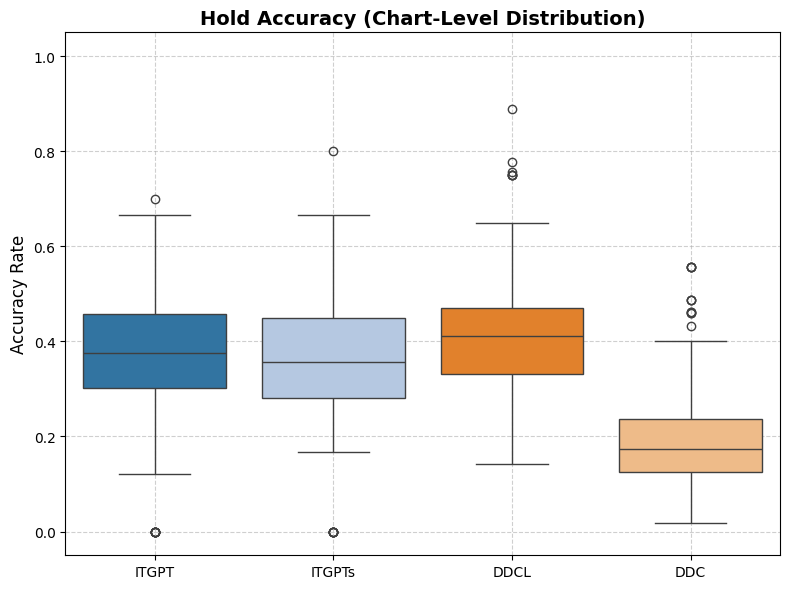

In [33]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_names = ['ITGPT', 'ITGPTs', 'DDCL', 'DDC']

# Point to the HoldAcc distribution lists for all models
hold_acc_sources = {
    'ITGPT': HoldAccs_chart,                               # List from live PyTorch loop
    'ITGPTs': HoldAccs_small_chart,                             # List from live PyTorch loop
    'DDCL': raw_chart_lists_ddcl['hold_accs'],                 # Full distribution list from Keras pickle
    'DDC': raw_chart_lists_ddc['hold_accs'],                   # Full distribution list from Keras pickle
}

# Match colors to the prior grid
model_colors = {
    'ITGPT': '#1f77b4',  # Royal Blue
    'ITGPTs': '#aec7e8',      # Light Blue
    'DDCL': '#ff7f0e',       # Dark Orange
    'DDC': '#ffbb78'         # Light Orange
}

values = []
models = []

for name in model_names:
    vals = hold_acc_sources[name]
    values.extend(vals)
    models.extend([name] * len(vals))

# Construct DataFrame
df_hold = pd.DataFrame({'Model': models, 'Hold Accuracy': values})

# Set up single plot figure
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    x='Model', 
    y='Hold Accuracy', 
    data=df_hold, 
    ax=ax, 
    palette=model_colors,
    hue='Model',
    legend=False
)

ax.set_title('Hold Accuracy (Chart-Level Distribution)', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy Rate', fontsize=12)
ax.set_xlabel('')
ax.set_ylim(-0.05, 1.05)  
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# Ensure destination folder exists
os.makedirs('figs', exist_ok=True)

plt.savefig('figs/hold_acc_comparison_sym.png', bbox_inches='tight', dpi=300)
plt.show()

In [17]:
# Breakdown of Top-K accuracy by chart difficulty, as a LaTeX table
# Uses accuracy_dict / accuracy_dict_small (per-difficulty, per-top-k) built during eval loops.
# DDCL/DDC only expose a single overall top-k accuracy (no per-difficulty breakdown available
# in keras_metric_dict), so they are reported as constant across difficulty rows.

top_ks = [1, 2, 3, 5]

all_diffs = sorted(set(accuracy_dict[1].keys()) | set(accuracy_dict_small[1].keys()))

rows = []
for d_level in all_diffs:
    row = {'Difficulty': d_level}
    for k in top_ks:
        big_vals = accuracy_dict[k].get(d_level, [])
        small_vals = accuracy_dict_small[k].get(d_level, [])
        row[f'ITGPT Big Top-{k}'] = np.mean(big_vals) if big_vals else np.nan
        row[f'ITGPT Top-{k}'] = np.mean(small_vals) if small_vals else np.nan
    rows.append(row)

df_diff = pd.DataFrame(rows)
df_diff_rounded = df_diff.copy()
df_diff_rounded.iloc[:, 1:] = df_diff_rounded.iloc[:, 1:].astype(float).round(4)

print(df_diff_rounded)

n_cols = df_diff_rounded.shape[1]
latex_diff_table = df_diff_rounded.to_latex(
    index=False,
    caption="Top-K Accuracy Breakdown by Chart Difficulty",
    label="tab:difficulty_topk_breakdown",
    column_format="l" + "c" * (n_cols - 1)
)
print(latex_diff_table)


AttributeError: 'list' object has no attribute 'keys'

FileNotFoundError: [Errno 2] No such file or directory: 'figs/topk_acc_by_chunk_sym.png'

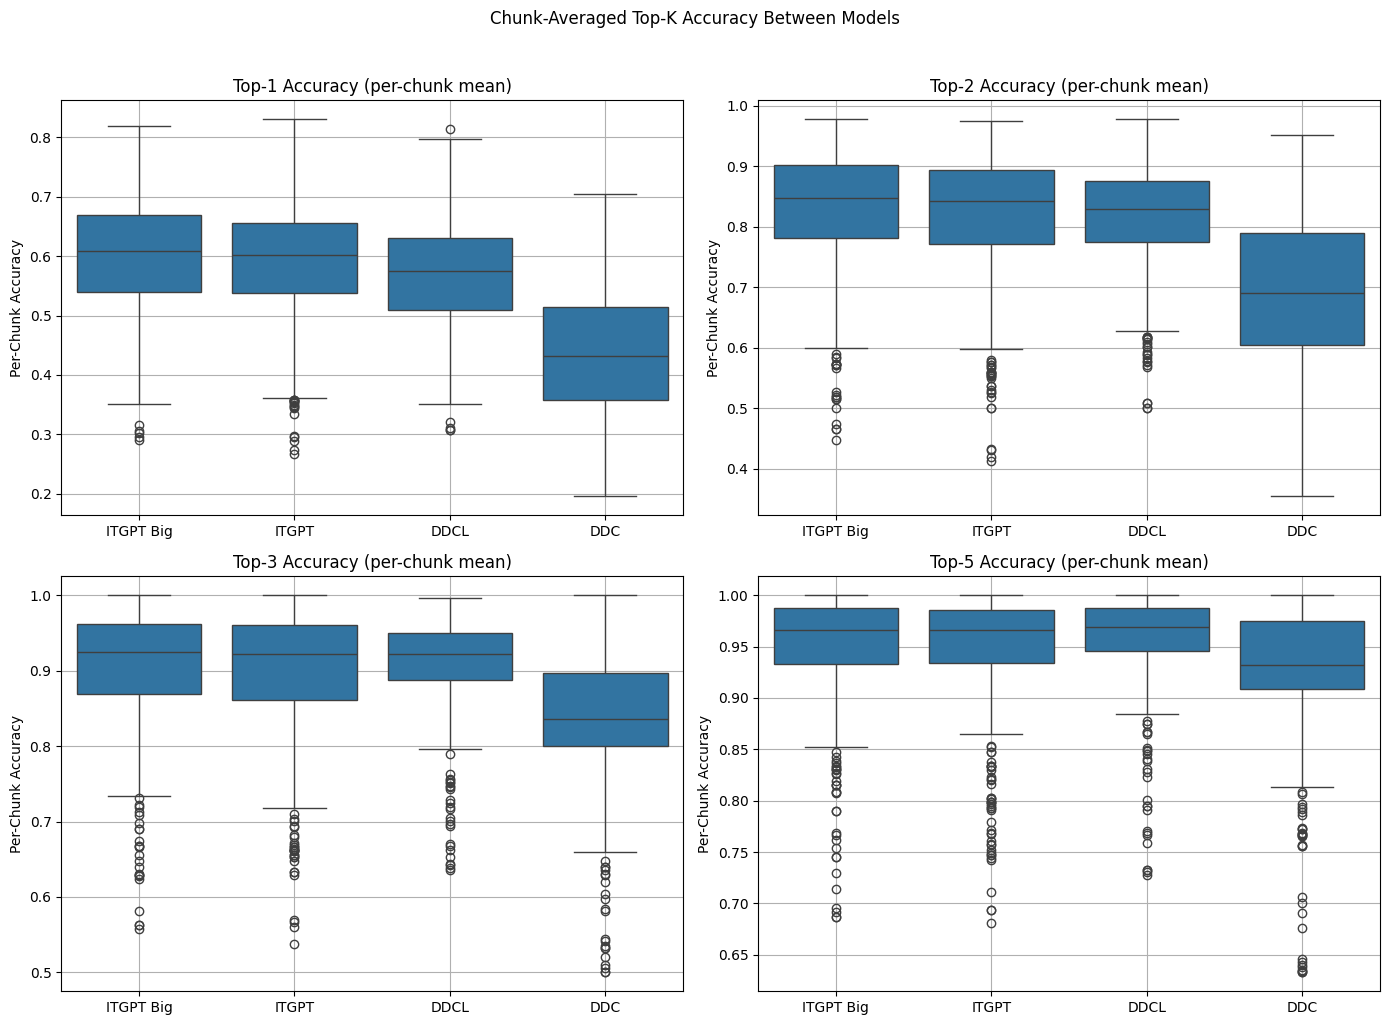

In [23]:
# Average-by-chunk Top-K accuracy: each entry in Accs[k]/Accs_small[k]/etc. is already
# a per-chunk mean (one value appended per chunk in the eval loops), so "average by chunk"
# for a model+k is np.mean(Accs[k]) -- the mean over those per-chunk means.
# This box plot shows the *distribution* of those per-chunk means across models, per top-k.

top_ks = [1, 2, 3, 5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

chunk_avg_rows = []

for ax, k in zip(axes, top_ks):
    values = []
    models = []
    for name in model_names:
        vals = acc_sources[name][k]  # per-chunk means, one per chunk
        values.extend(vals)
        models.extend([name] * len(vals))
        chunk_avg_rows.append({
            'Model': name,
            'Top-K': k,
            'Mean of per-chunk means': np.mean(vals) if vals else np.nan
        })

    df_k = pd.DataFrame({'Model': models, 'Per-Chunk Accuracy': values})
    sns.boxplot(x='Model', y='Per-Chunk Accuracy', data=df_k, ax=ax)
    ax.set_title(f'Top-{k} Accuracy (per-chunk mean)')
    ax.set_xlabel('')
    ax.grid(True)

fig.suptitle('Chunk-Averaged Top-K Accuracy Between Models', y=1.02)
plt.tight_layout()
plt.savefig('figs/topk_acc_by_chunk_sym.png', bbox_inches='tight')
plt.show()

df_chunk_avg = pd.DataFrame(chunk_avg_rows)
print(df_chunk_avg.pivot(index='Model', columns='Top-K', values='Mean of per-chunk means'))
